In [ ]:
image_path = '/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/prod/images/'

In [10]:
import numpy as np
from PIL import Image
from pathlib import Path

class ImageProcessor:
    def __init__(self):
        self.processed_images = {}  # Dictionary to store processed images
        self.pixel_data = {}       # Dictionary to store pixel data
    
    def process_image(self, image_path):
        """
        Load and resize image to 1000px width while maintaining aspect ratio
        
        Args:
            image_path: Path to the image file
            
        Returns:
            dict containing processed image data
        """
        # Load image
        img = Image.open(image_path)
        original_size = img.size
        
        # Calculate new height maintaining aspect ratio
        width_percent = (1000 / float(img.size[0]))
        new_height = int((float(img.size[1]) * float(width_percent)))
        
        # Resize image
        img = img.resize((1000, new_height), Image.Resampling.LANCZOS)
        
        # Convert to numpy array
        img_array = np.array(img)
        
        # Store data in dictionary
        image_info = {
            'file_path': str(image_path),
            'file_name': Path(image_path).name,
            'original_size': original_size,
            'resized_shape': img_array.shape,
            'array': img_array
        }
        
        # Store in class dictionary
        self.processed_images[str(image_path)] = image_info
        
        print(f"Processed: {Path(image_path).name}")
        print(f"Original size: {original_size}")
        print(f"Resized to: {img_array.shape}")
        
        return image_info
    
    def extract_pixel_data(self, image_path):
        """
        Extract pixel data (R,G,B,X,Y) from processed image
        
        Args:
            image_path: Path to the processed image
            
        Returns:
            numpy array of shape (n_pixels, 5) containing [R,G,B,X,Y] for each pixel
        """
        if str(image_path) not in self.processed_images:
            raise ValueError(f"Image {image_path} not processed yet")
            
        img_array = self.processed_images[str(image_path)]['array']
        height, width = img_array.shape[:2]
        
        # Create meshgrid for X,Y coordinates
        y_coords, x_coords = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
        
        # Normalize X,Y coordinates to 0-1 range
        x_normalized = x_coords / width
        y_normalized = y_coords / height
        
        # Reshape arrays
        pixels_rgb = img_array.reshape(-1, 3)  # RGB values
        x_coords = x_normalized.reshape(-1, 1)  # X coordinates
        y_coords = y_normalized.reshape(-1, 1)  # Y coordinates
        
        # Combine all data
        pixel_data = np.column_stack([pixels_rgb, x_coords, y_coords])
        
        # Store in class dictionary
        self.pixel_data[str(image_path)] = pixel_data
        
        print(f"Extracted pixel data for: {Path(image_path).name}")
        print(f"Shape: {pixel_data.shape} (n_pixels, [R,G,B,X,Y])")
        
        return pixel_data
    
    def process_input(self, input_path):
        """
        Process either a single image or all images in a directory
        
        Args:
            input_path: Path to a single image file or a directory
            
        Returns:
            dict containing processed images and their pixel data
        """
        path = Path(input_path)
        
        if path.is_file():
            # Process single image
            if path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                try:
                    # Process image
                    self.process_image(str(path))
                    # Extract pixel data
                    self.extract_pixel_data(str(path))
                except Exception as e:
                    print(f"Error processing {path.name}: {e}")
            else:
                print(f"Unsupported file type: {path.suffix}")
        
        elif path.is_dir():
            # Process all images in directory
            for file_path in path.glob('*'):
                if file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    try:
                        # Process image
                        self.process_image(str(file_path))
                        # Extract pixel data
                        self.extract_pixel_data(str(file_path))
                    except Exception as e:
                        print(f"Error processing {file_path.name}: {e}")
        
        else:
            print("Invalid input: must be a file or directory")
        
        print(f"\nTotal images processed: {len(self.processed_images)}")
        return self.pixel_data
    
    def get_pixel_data(self):
        """
        Get pixel data for all processed images
        
        Returns:
            dict with file paths as keys and pixel data arrays as values
        """
        return self.pixel_data

# Example usage:

# Initialize processor
processor = ImageProcessor()

# Process a single image
# single_image_pixels = processor.process_input('/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/prod/images/test3.jpg')

# Process an entire directory
directory_pixel_data = processor.process_input('/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/prod/images/')

# Get all processed pixel data
all_pixel_data = processor.get_pixel_data()

Processed: test4.jpg
Original size: (300, 200)
Resized to: (666, 1000, 3)
Extracted pixel data for: test4.jpg
Shape: (666000, 5) (n_pixels, [R,G,B,X,Y])
Processed: test3.jpg
Original size: (300, 200)
Resized to: (666, 1000, 3)
Extracted pixel data for: test3.jpg
Shape: (666000, 5) (n_pixels, [R,G,B,X,Y])
Processed: test2.jpg
Original size: (6000, 4000)
Resized to: (666, 1000, 3)
Extracted pixel data for: test2.jpg
Shape: (666000, 5) (n_pixels, [R,G,B,X,Y])

Total images processed: 3


Processed: test4.jpg
Original size: (300, 200)
Resized to: (200, 300, 3)
Extracted pixel data for: test4.jpg
Shape: (60000, 5) (n_pixels, [R,G,B,X,Y])

Processing UMAP for: test4.jpg


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[9.77157224e-15 7.99690935e-07 1.76873821e-06

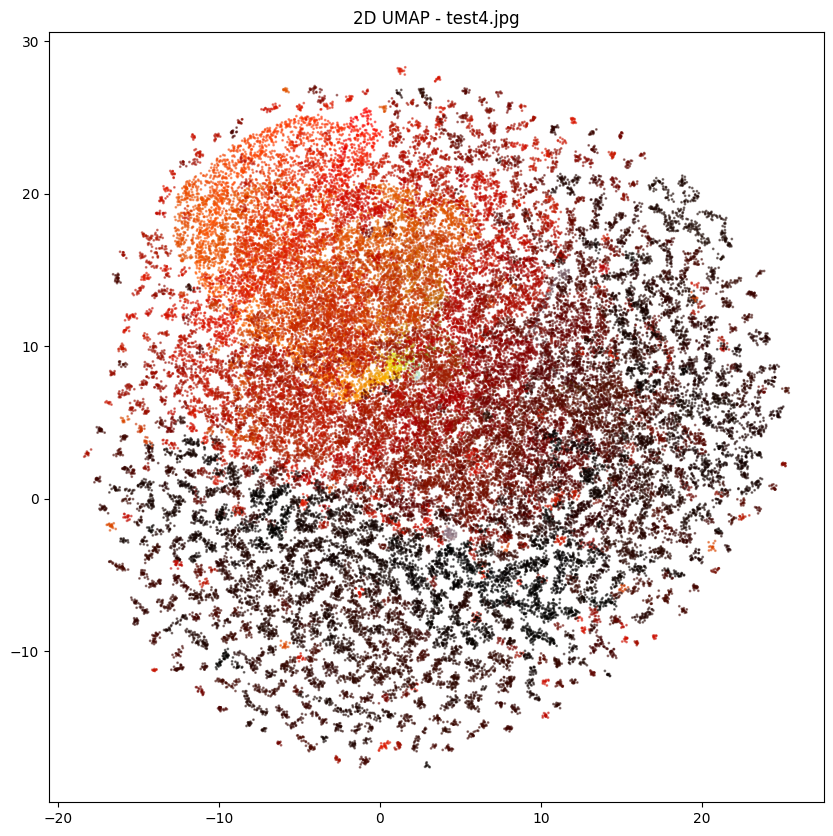

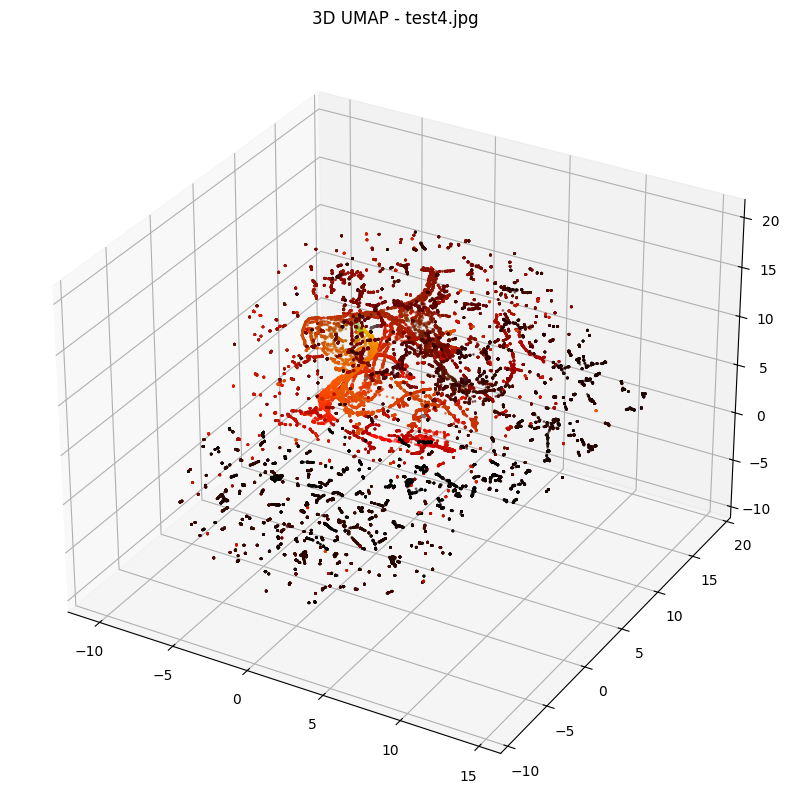

UMAP shapes - 2D: (60000, 2), 3D: (60000, 3)
Processed: test3.jpg
Original size: (300, 200)
Resized to: (200, 300, 3)
Extracted pixel data for: test3.jpg
Shape: (60000, 5) (n_pixels, [R,G,B,X,Y])

Processing UMAP for: test3.jpg


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warni

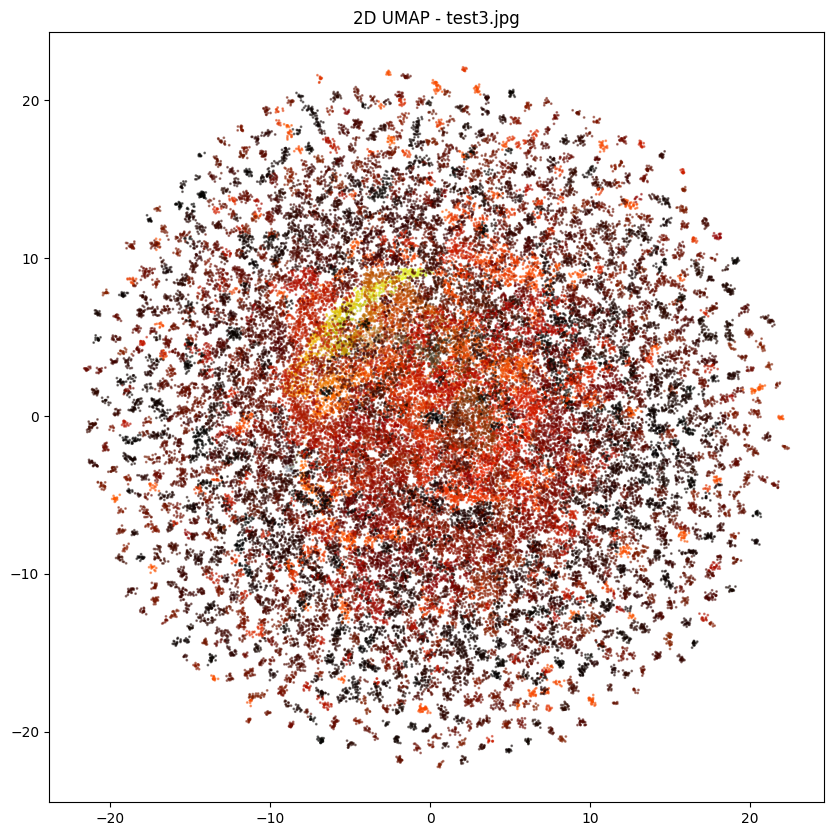

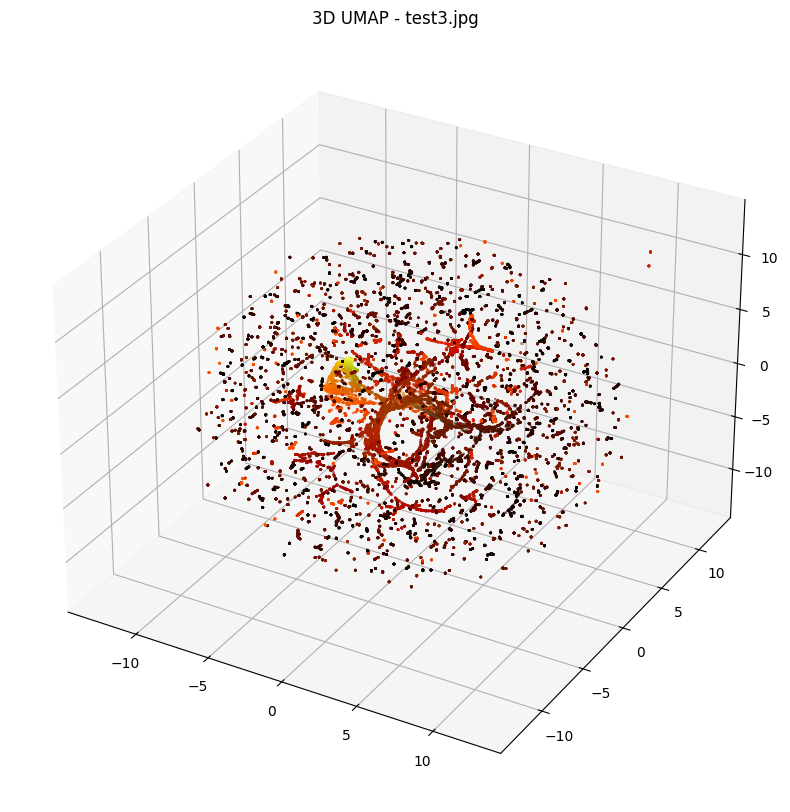

UMAP shapes - 2D: (60000, 2), 3D: (60000, 3)
Processed: test2.jpg
Original size: (6000, 4000)
Resized to: (200, 300, 3)
Extracted pixel data for: test2.jpg
Shape: (60000, 5) (n_pixels, [R,G,B,X,Y])

Processing UMAP for: test2.jpg


/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warni

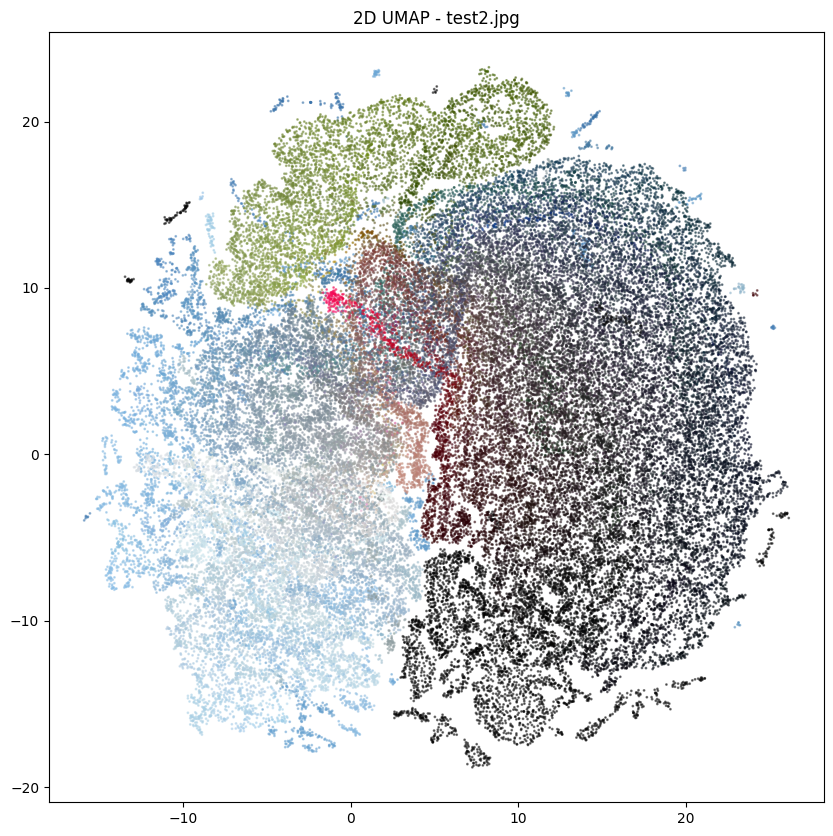

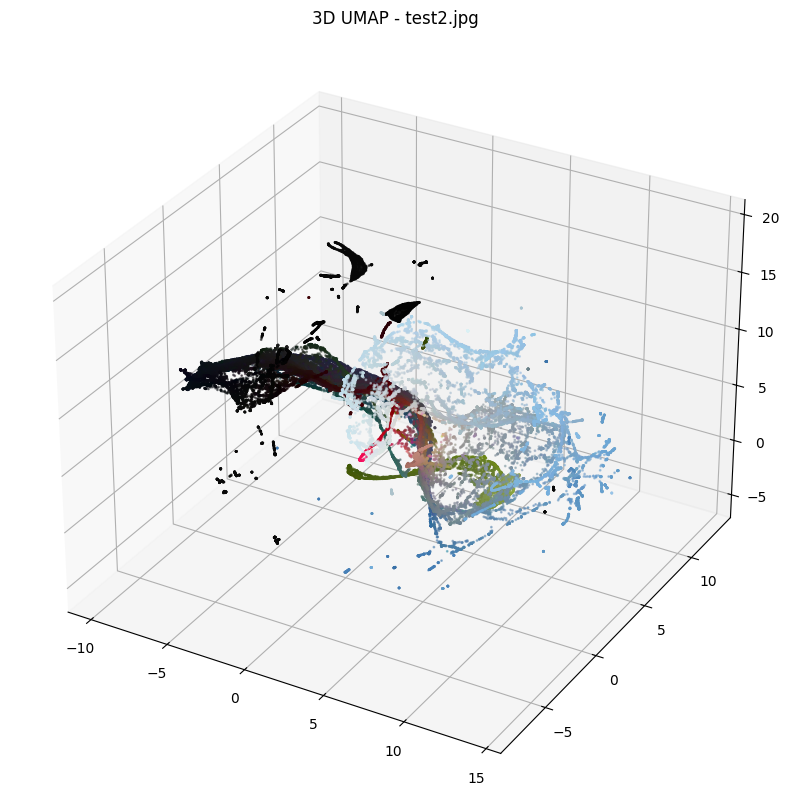

UMAP shapes - 2D: (60000, 2), 3D: (60000, 3)

Total images processed: 3


In [14]:
import numpy as np
from PIL import Image
from pathlib import Path
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def process_image(image_path):
    """
    Load and resize image to 1000px width while maintaining aspect ratio
    """
    # Load image
    img = Image.open(image_path)
    original_size = img.size
    
    # Calculate new height maintaining aspect ratio
    width_percent = (300 / float(img.size[0]))
    new_height = int((float(img.size[1]) * float(width_percent)))
    
    # Resize image
    img = img.resize((300, new_height), Image.Resampling.LANCZOS)
    
    # Convert to numpy array
    img_array = np.array(img)
    
    print(f"Processed: {Path(image_path).name}")
    print(f"Original size: {original_size}")
    print(f"Resized to: {img_array.shape}")
    
    return {
        'file_path': str(image_path),
        'file_name': Path(image_path).name,
        'original_size': original_size,
        'resized_shape': img_array.shape,
        'array': img_array
    }

def extract_pixel_data(img_info):
    """
    Extract pixel data (R,G,B,X,Y) from image
    """
    img_array = img_info['array']
    height, width = img_array.shape[:2]
    
    # Create meshgrid for X,Y coordinates
    y_coords, x_coords = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
    
    # Normalize X,Y coordinates to 0-1 range
    x_normalized = x_coords / width
    y_normalized = y_coords / height
    
    # Reshape arrays
    pixels_rgb = img_array.reshape(-1, 3)
    x_coords = x_normalized.reshape(-1, 1)
    y_coords = y_normalized.reshape(-1, 1)
    
    # Combine all data
    pixel_data = np.column_stack([pixels_rgb, x_coords, y_coords])
    
    print(f"Extracted pixel data for: {img_info['file_name']}")
    print(f"Shape: {pixel_data.shape} (n_pixels, [R,G,B,X,Y])")
    
    return pixel_data

def create_umaps(pixel_data, filename):
    """
    Create and plot both 2D and 3D UMAP visualizations
    """
    # UMAP reducers
    reducer_2d = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=1,
        metric='euclidean',
        random_state=42
    )
    
    reducer_3d = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )
    
    print(f"\nProcessing UMAP for: {filename}")
    
    # Create embeddings
    embedding_2d = reducer_2d.fit_transform(pixel_data)
    embedding_3d = reducer_3d.fit_transform(pixel_data)
    
    # Plot 2D UMAP
    plt.figure(figsize=(10, 10))
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
               c=pixel_data[:, :3]/255,
               s=1,
               alpha=0.5)
    plt.title(f'2D UMAP - {filename}')
    plt.show()
    
    # Plot 3D UMAP
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(embedding_3d[:, 0], 
                       embedding_3d[:, 1], 
                       embedding_3d[:, 2],
                       c=pixel_data[:, :3]/255,
                       s=1,
                       alpha=0.5)
    ax.set_title(f'3D UMAP - {filename}')
    plt.show()
    
    print(f"UMAP shapes - 2D: {embedding_2d.shape}, 3D: {embedding_3d.shape}")
    
    return {
        '2d': embedding_2d,
        '3d': embedding_3d
    }

def process_input(input_path):
    """
    Process either a single image or all images in a directory
    
    Args:
        input_path: Path to image file or directory
        
    Returns:
        Dictionary containing processed data
    """
    processed_data = {}
    path = Path(input_path)
    
    if path.is_file():
        # Process single image
        if path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            try:
                # Process image
                img_info = process_image(str(path))
                
                # Extract pixel data
                pixels = extract_pixel_data(img_info)
                
                # Create UMAP visualizations
                umaps = create_umaps(pixels, img_info['file_name'])
                
                # Store all data
                processed_data[str(path)] = {
                    'image_info': img_info,
                    'pixel_data': pixels,
                    'umap_data': umaps
                }
            except Exception as e:
                print(f"Error processing {path.name}: {e}")
        else:
            print(f"Unsupported file type: {path.suffix}")
            
    elif path.is_dir():
        # Process all images in directory
        for file_path in path.glob('*'):
            if file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                try:
                    # Process image
                    img_info = process_image(str(file_path))
                    
                    # Extract pixel data
                    pixels = extract_pixel_data(img_info)
                    
                    # Create UMAP visualizations
                    umaps = create_umaps(pixels, img_info['file_name'])
                    
                    # Store all data
                    processed_data[str(file_path)] = {
                        'image_info': img_info,
                        'pixel_data': pixels,
                        'umap_data': umaps
                    }
                except Exception as e:
                    print(f"Error processing {file_path.name}: {e}")
    
    else:
        print("Invalid input: must be a file or directory")
        
    print(f"\nTotal images processed: {len(processed_data)}")
    return processed_data

# Usage for single image:
# processed_data = process_input(image_path)

# Usage for directory:
processed_data = process_input('/Users/matthewlaujh/Desktop/desktop/itpnyu/itpnyu-thesis/itpnyu-thesis/prod/images/')

In [20]:
def generate_umap_header(umap_data, pixel_colors, mapping='2d'):
    """
    Generate Arduino header file that represents the UMAP visualization
    using the actual colors from the UMAP plot
    
    Args:
        umap_data: Dictionary containing UMAP embeddings
        pixel_colors: Original RGB values from the image pixels
        mapping: '2d' or '3d' to choose which mapping to use
    """
    header = """// UMAP LED mapping data
#ifndef UMAP_DATA_H
#define UMAP_DATA_H

struct LEDPoint {
  uint8_t x;
  uint8_t y;
  uint8_t r;
  uint8_t g;
  uint8_t b;
};

const LEDPoint umapData[64] = {
"""
    
    # Get embeddings
    embedding = umap_data[mapping]
    
    # Normalize embeddings to 0-1 range for position mapping
    embedding_norm = (embedding - embedding.min(axis=0)) / (embedding.max(axis=0) - embedding.min(axis=0))
    
    # Create a spatial grid for the LED matrix
    led_data = []
    for i in range(8):
        for j in range(8):
            # Map LED position to UMAP space coordinates
            # Use the full range of the UMAP space
            umap_x = -25 + (i/7.0) * 50  # Adjust range based on your UMAP plot
            umap_y = -25 + (j/7.0) * 50  # Adjust range based on your UMAP plot
            
            # Find points in UMAP space near this LED position
            distances = np.sqrt(
                (embedding[:, 0] - umap_x)**2 + 
                (embedding[:, 1] - umap_y)**2
            )
            
            # Get nearest points
            nearest_indices = np.argsort(distances)[:5]
            weights = 1 / (distances[nearest_indices] + 1e-6)
            weights = weights / weights.sum()
            
            # Get weighted average of colors from nearby points
            r = int(np.sum(pixel_colors[nearest_indices, 0] * weights))
            g = int(np.sum(pixel_colors[nearest_indices, 1] * weights))
            b = int(np.sum(pixel_colors[nearest_indices, 2] * weights))
            
            led_data.append({
                'x': i,
                'y': j,
                'r': min(255, max(0, r)),
                'g': min(255, max(0, g)),
                'b': min(255, max(0, b))
            })
    
    # Generate struct initialization
    for idx, led in enumerate(led_data):
        header += f"  {{{led['x']}, {led['y']}, {led['r']}, {led['g']}, {led['b']}}}"
        if idx < len(led_data) - 1:
            header += ","
        header += "\n"
    
    header += "};\n\n#endif"
    
    return header

def save_umap_header(filename, header_content):
    """
    Save header file
    """
    with open(filename, 'w') as f:
        f.write(header_content)

# Example usage:
# After processing your image and extracting UMAP embeddings:
header_content = generate_umap_header(
    processed_data[image_path]['umap_data'],
    processed_data[image_path]['pixel_data'][:, :3],
    mapping='2d'
)
save_umap_header('umap_data6.h', header_content)

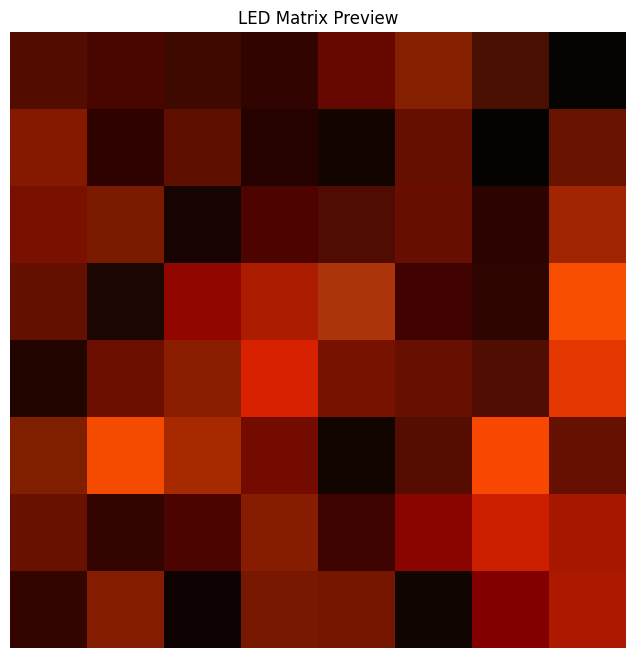

In [21]:
def preview_led_matrix(header_content):
    """
    Preview what the LED matrix will look like
    """
    # Extract RGB values from header content
    import re
    pattern = r'\{(\d+),\s*(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\}'
    matches = re.findall(pattern, header_content)
    
    # Create 8x8x3 array for RGB values
    matrix = np.zeros((8, 8, 3), dtype=np.uint8)
    
    for match in matches:
        x, y, r, g, b = map(int, match)
        matrix[x, y] = [r, g, b]
    
    # Display using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(matrix)
    plt.title('LED Matrix Preview')
    plt.axis('off')
    plt.show()

preview_led_matrix(header_content)
